# DATA 612 Final Project Planning Document  
## Aaliyah John-Harry  
### Hybrid Movie Recommendation System Using MovieLens 1M and External Movie Metadata

## Project Overview

For my final project, I plan to build a hybrid movie recommender system using the **MovieLens 1M dataset** combined with additional movie metadata from an external source, **The Movie Database (TMDb)**.

Throughout this course, I've implemented several recommendation approaches, including baseline predictors, content-based filtering, collaborative filtering, matrix factorization, and Spark-based ALS. Unlike my previous assignments, which used the smaller MovieLens dataset, this project will use the MovieLens 1M dataset, which contains over one million ratings. In addition to enriching the dataset with metadata from TMDb, I plan to incorporate poster image analysis by extracting visual features from movie posters using a pre-trained convolutional neural network if time permits. These images will provide additional information about each movie's style, color palette, and artwork, allowing the recommender to leverage both textual and visual information when generating recommendations.

The main goal is to produce quality movie recommendations by extracting patterns from a large ratings dataset while also using movie metadata to make the recommendations more informative and diverse.

## Primary Dataset

The primary dataset for this project will be the **MovieLens 1M** dataset from GroupLens Research.

This dataset contains approximately:

| Component | Description |
|---|---|
| Ratings | 1,000,209 ratings |
| Users | 6,040 users |
| Movies | About 3,706 movies |
| Rating Scale | 1 to 5 stars |
| Metadata | Movie titles, genres, user age, gender, occupation, and timestamps |

### Additional Data

To make the project more unique and avoid simply repeating earlier MovieLens assignments, I plan to add external movie metadata from **TMDb**, a publicly available movie metadata source.

Potential additional features include:

- Movie overview or description
- Release year
- Runtime
- Popularity score
- Average TMDb rating
- Keywords
- Expanded genre information

These features can improve the content-based part of the recommender and help the system recommend movies that are similar in theme, style, or topic, not just movies that received similar ratings.


### Poster Image Analysis

In addition to textual metadata, I plan to incorporate movie poster images obtained through TMDb. Rather than using the raw images directly, I will extract high-level visual features using a pre-trained CNN such as ResNet50 or EfficientNetB0. These models produce numerical feature vectors (embeddings) that capture visual characteristics including color, composition, and artistic style.

I plan to incorporate these image embeddings into the content-based component of the recommender and combine it with movie metadata to provide a richer representation of each movie. This may improve recommendations for visually similar films that share themes or styles not fully captured by genres or descriptions alone.

## Recommendation System Plan

The final system will compare three recommendation approaches:

1. **ALS Collaborative Filtering**  
   Uses user-item rating patterns to learn latent user and movie factors.

2. **Content-Based Filtering**  
   Uses movie genres, descriptions, and other metadata to recommend similar movies.

3. **Hybrid Recommender**  
   Combines collaborative filtering scores with content-based similarity scores.

## Planned Evaluation

The final project recommender system will be evaluated using both accuracy-focused and ranking-focused metrics.

### Prediction Metric

- RMSE

### Ranking Metrics

- Precision@10
- Recall@10
- NDCG@10

### Beyond-Accuracy Metrics

- Novelty@10
- Diversity@10
- Catalog coverage

The final results will compare ALS, content-based filtering, and the hybrid model to determine whether combining ratings data with external movie metadata improves recommendation quality.

## Tools and Technologies

This project will use:

- Python
- Pandas
- NumPy
- Scikit-learn
- PySpark / Spark MLlib ALS
- Matplotlib
- Jupyter Notebook

Spark is a good fit for this project because the MovieLens 1M dataset is larger than the smaller datasets used earlier in the course, and Spark ALS is designed for scalable matrix factorization.

## Expected Outcome

I expect the hybrid recommender system to outperform the individual recommendation approaches by leveraging the strengths of both collaborative filtering and content-based filtering. The ALS model will capture latent user preferences from the large MovieLens 1M ratings dataset, while the content-based component will use movie metadata and textual descriptions to identify similarities between movies.

By incorporating visual features extracted from the movie posters, the recommender will also be able to capture stylistic characteristics that are not reflected in ratings or textual metadata alone. This additional source of information may improve recommendations for movies with similar visual themes, genres, or artistic styles.

Overall, I expect the hybrid model to generate recommendations that are more accurate, diverse, and explainable than using collaborative filtering or content-based filtering individually. I included movie metadata and poster image features- this should help to mitigate the new item cold-start problem by allowing the recommender to identify similar movies even when a movie has received relatively few user ratings.

## Potential Challenges

Some possible challenges include:

- Merging MovieLens movie records with external metadata.
- Managing the larger dataset efficiently.
- Tuning ALS parameters without spending too much time on computation.
- Creating a fair evaluation process for comparing ALS, content-based filtering, and the hybrid recommender.

To keep the project manageable, the primary focus will be on building a working hybrid recommender. Additional features such as poster image analysis will only be considered if time allows.

# Quick Data Exploration

The following cells load the MovieLens 1M dataset and perform a quick exploratory analysis. If the data is not already available locally, the notebook will download it from GroupLens.

In [1]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 50)

In [2]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

zip_path = DATA_DIR / 'ml-1m.zip'
extract_dir = DATA_DIR / 'ml-1m'
url = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'

if not extract_dir.exists():
    if not zip_path.exists():
        print('Downloading MovieLens 1M dataset...')
        urllib.request.urlretrieve(url, zip_path)
    
    print('Extracting files...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
else:
    print('MovieLens 1M dataset already found locally.')

MovieLens 1M dataset already found locally.


In [4]:
ratings_path = extract_dir / 'ratings.dat'
movies_path = extract_dir / 'movies.dat'
users_path = extract_dir / 'users.dat'

ratings = pd.read_csv(
    ratings_path,
    sep='::',
    engine='python',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1'
)

movies = pd.read_csv(
    movies_path,
    sep='::',
    engine='python',
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1'
)

users = pd.read_csv(
    users_path,
    sep='::',
    engine='python',
    names=['user_id', 'gender', 'age', 'occupation', 'zip_code'],
    encoding='latin-1'
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
links_zip_path = DATA_DIR / 'ml-latest-small.zip'
links_extract_dir = DATA_DIR / 'ml-latest-small'
links_url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

if not links_extract_dir.exists():
    if not links_zip_path.exists():
        print('Downloading MovieLens latest-small for links.csv...')
        urllib.request.urlretrieve(links_url, links_zip_path)
    
    print('Extracting links.csv...')
    with zipfile.ZipFile(links_zip_path, 'r') as z:
        z.extractall(DATA_DIR)
else:
    print('MovieLens latest-small links data already found locally.')

links_path = links_extract_dir / 'links.csv'
links = pd.read_csv(links_path)
links.head()

MovieLens latest-small links data already found locally.


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [7]:
movies_with_links = movies.merge(
    links.rename(columns={'movieId': 'movie_id'}),
    on='movie_id',
    how='left'
)

match_rate = movies_with_links['tmdbId'].notna().mean()
print(f'TMDb ID match rate: {match_rate:.1%}')
print(f"Movies with TMDb IDs: {movies_with_links['tmdbId'].notna().sum():,} out of {len(movies_with_links):,}")

movies_with_links['tmdb_url'] = movies_with_links['tmdbId'].apply(
    lambda x: f'https://www.themoviedb.org/movie/{int(x)}' if pd.notna(x) else np.nan
)

movies_with_links[['movie_id', 'title', 'genres', 'imdbId', 'tmdbId', 'tmdb_url']].head(10)

TMDb ID match rate: 75.9%
Movies with TMDb IDs: 2,946 out of 3,883


,movie_id,title,genres,imdbId,tmdbId,tmdb_url
0,1,Toy Story (1995),Animation|Children's|Comedy,114709.0,862.0,https://www.themoviedb.org/movie/862
1,2,Jumanji (1995),Adventure|Children's|Fantasy,113497.0,8844.0,https://www.themoviedb.org/movie/8844
2,3,Grumpier Old Men (1995),Comedy|Romance,113228.0,15602.0,https://www.themoviedb.org/movie/15602
3,4,Waiting to Exhale (1995),Comedy|Drama,114885.0,31357.0,https://www.themoviedb.org/movie/31357
4,5,Father of the Bride Part II (1995),Comedy,113041.0,11862.0,https://www.themoviedb.org/movie/11862
5,6,Heat (1995),Action|Crime|Thriller,113277.0,949.0,https://www.themoviedb.org/movie/949
6,7,Sabrina (1995),Comedy|Romance,114319.0,11860.0,https://www.themoviedb.org/movie/11860
7,8,Tom and Huck (1995),Adventure|Children's,112302.0,45325.0,https://www.themoviedb.org/movie/45325
8,9,Sudden Death (1995),Action,114576.0,9091.0,https://www.themoviedb.org/movie/9091
9,10,GoldenEye (1995),Action|Adventure|Thriller,113189.0,710.0,https://www.themoviedb.org/movie/710


In [9]:
summary = pd.DataFrame({
    'Metric': [
        'Number of ratings',
        'Number of users',
        'Number of movies in ratings',
        'Number of movies in movie metadata',
        'Average rating',
        'Minimum rating',
        'Maximum rating'
    ],
    'Value': [
        len(ratings),
        ratings['user_id'].nunique(),
        ratings['movie_id'].nunique(),
        movies['movie_id'].nunique(),
        round(ratings['rating'].mean(), 3),
        ratings['rating'].min(),
        ratings['rating'].max()
    ]
})

summary

,Metric,Value
0,Number of ratings,1000209.000
1,Number of users,6040.000
2,Number of movies in ratings,3706.000
3,Number of movies in movie metadata,3883.000
4,Average rating,3.582
5,Minimum rating,1.000
6,Maximum rating,5.000


In [10]:
# Check missing values
missing_summary = pd.DataFrame({
    'ratings_missing': ratings.isna().sum(),
}).T

missing_summary

,user_id,movie_id,rating,timestamp
ratings_missing,0,0,0,0


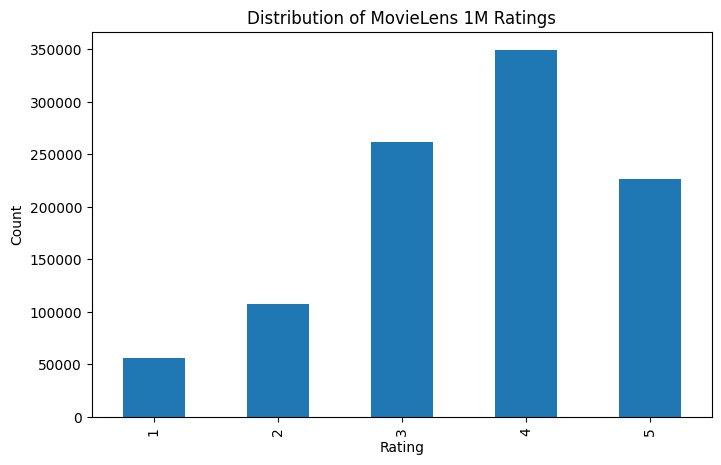

In [11]:
# Rating distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of MovieLens 1M Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [12]:
# Ratings per user
ratings_per_user = ratings.groupby('user_id')['rating'].count()
ratings_per_user.describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: rating, dtype: float64

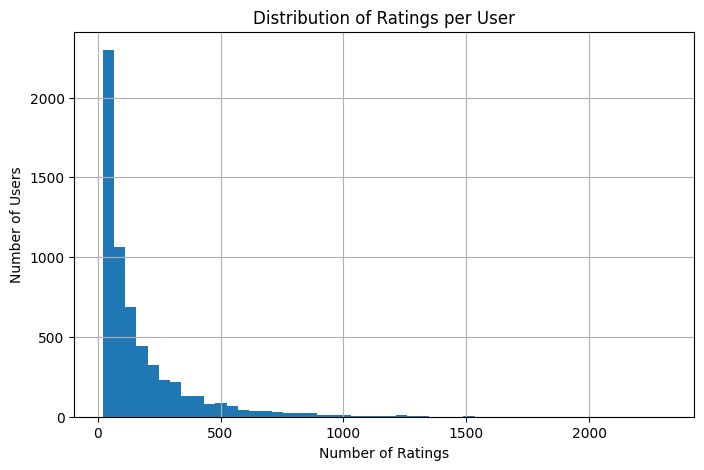

In [13]:
ratings_per_user.hist(bins=50)
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()

In [14]:
# Ratings per movie
ratings_per_movie = ratings.groupby('movie_id')['rating'].count()
ratings_per_movie.describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: rating, dtype: float64

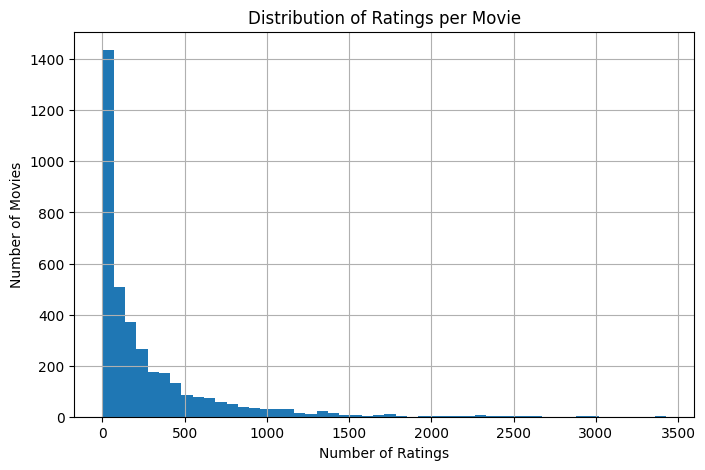

In [15]:
ratings_per_movie.hist(bins=50)
plt.title('Distribution of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.show()

In [16]:
# Most-rated movies
movie_rating_counts = (
    ratings.groupby('movie_id')
    .agg(num_ratings=('rating', 'count'), avg_rating=('rating', 'mean'))
    .reset_index()
    .merge(movies, on='movie_id', how='left')
    .sort_values('num_ratings', ascending=False)
)

movie_rating_counts.head(10)

,movie_id,num_ratings,avg_rating,title,genres
2651,2858,3428,4.317386,American Beauty (1999),Comedy|Drama
253,260,2991,4.453694,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi
1106,1196,2990,4.292977,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
1120,1210,2883,4.022893,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War
466,480,2672,3.763847,Jurassic Park (1993),Action|Adventure|Sci-Fi
1848,2028,2653,4.337354,Saving Private Ryan (1998),Action|Drama|War
575,589,2649,4.058513,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller
2374,2571,2590,4.315830,"Matrix, The (1999)",Action|Sci-Fi|Thriller
1178,1270,2583,3.990321,Back to the Future (1985),Comedy|Sci-Fi
579,593,2578,4.351823,"Silence of the Lambs, The (1991)",Drama|Thriller


In [17]:
# Highest-rated movies with at least 100 ratings
popular_high_rated = movie_rating_counts[movie_rating_counts['num_ratings'] >= 100].sort_values(
    ['avg_rating', 'num_ratings'], ascending=False
)

popular_high_rated.head(10)

,movie_id,num_ratings,avg_rating,title,genres
1839,2019,628,4.560510,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama
309,318,2227,4.554558,"Shawshank Redemption, The (1994)",Drama
802,858,2223,4.524966,"Godfather, The (1972)",Action|Crime|Drama
708,745,657,4.520548,"Close Shave, A (1995)",Animation|Comedy|Thriller
49,50,1783,4.517106,"Usual Suspects, The (1995)",Crime|Thriller
513,527,2304,4.510417,Schindler's List (1993),Drama|War
1066,1148,882,4.507937,"Wrong Trousers, The (1993)",Animation|Comedy
861,922,470,4.491489,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir
1108,1198,2514,4.477725,Raiders of the Lost Ark (1981),Action|Adventure
843,904,1050,4.476190,Rear Window (1954),Mystery|Thriller


In [18]:
# Explore genre frequency
movies_exploded = movies.copy()
movies_exploded['genre'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genre')

genre_counts = movies_exploded['genre'].value_counts()
genre_counts

genre
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: count, dtype: int64

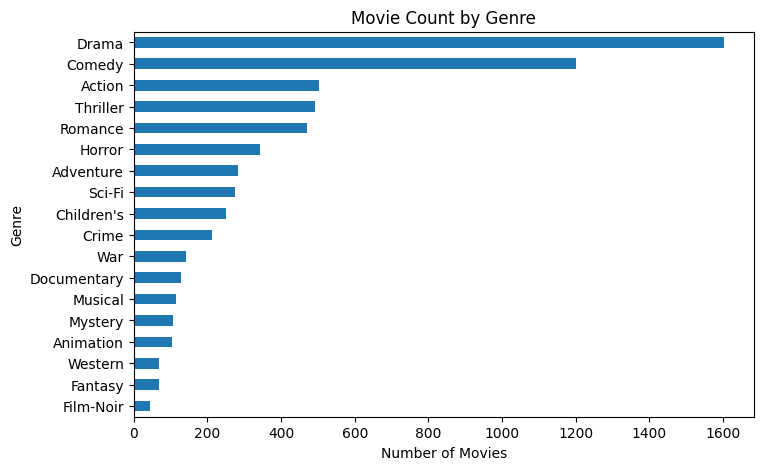

In [19]:
genre_counts.sort_values().plot(kind='barh')
plt.title('Movie Count by Genre')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

In [20]:
# Merge ratings with movie and user metadata for future modeling
ratings_full = ratings.merge(movies, on='movie_id', how='left').merge(users, on='user_id', how='left')
ratings_full.head()

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067


In [21]:
# Sparsity of the user-item matrix
num_users = ratings['user_id'].nunique()
num_movies = ratings['movie_id'].nunique()
num_possible_ratings = num_users * num_movies
num_observed_ratings = len(ratings)
sparsity = 1 - (num_observed_ratings / num_possible_ratings)

print(f'Users: {num_users:,}')
print(f'Movies: {num_movies:,}')
print(f'Observed ratings: {num_observed_ratings:,}')
print(f'Possible user-movie pairs: {num_possible_ratings:,}')
print(f'Sparsity: {sparsity:.2%}')

Users: 6,040
Movies: 3,706
Observed ratings: 1,000,209
Possible user-movie pairs: 22,384,240
Sparsity: 95.53%
